# Interpretabilidade e Discussão Crítica — Câncer Cervical

**Dataset:** [Cervical Cancer (Risk Factors)](https://archive.ics.uci.edu/dataset/383/cervical+cancer+risk+factors) — UCI Machine Learning Repository

**Variável-alvo:** `Biopsy` (0 = biópsia negativa, 1 = biópsia positiva)

**Objetivo desta etapa:** entender **por que** o modelo final toma as decisões que
toma (feature importance e SHAP) e discutir, de forma crítica e honesta, se e como
ele poderia apoiar um uso prático. Esta é **apenas a etapa de interpretabilidade**.
Preparação para produção (deploy, API, monitoramento) fica fora do escopo deste
notebook.

### O que já sabemos das etapas anteriores (resumo)

1. **Modelo final:** Random Forest (`n_estimators=400`, `max_depth=None`,
   `min_samples_leaf=1`), treinado com SMOTE dentro de cada fold — carregado aqui
   **sem retreino**.
2. **Limiar calibrado:** em vez do limiar padrão (0,5), usamos o limiar calibrado na
   etapa anterior (critério: maior limiar que garante Recall ≥ 70% no teste).
3. **Limitações que já conhecemos e que continuam valendo aqui:**
   - Apenas 11 casos positivos no teste — qualquer análise é sensível a ruído
     amostral, e isso vale também para o SHAP.
   - A calibração de limiar usou o próprio conjunto de teste (não havia conjunto de
     validação separado).
   - A meta de Recall mínimo (70%) foi uma escolha razoável, mas arbitrária.
   - A Regressão Logística não pôde ser comparada por não ter sido exportada como
     artefato.

Este notebook foi desenvolvido para rodar no **Google Colab**, usando `pandas`,
`numpy`, `scikit-learn`, `matplotlib`, `seaborn` e `shap`.


## 0. Configuração do ambiente

`shap` não vem pré-instalada no Colab, então garantimos sua instalação antes de importar.

In [1]:
try:
    import shap  # noqa: F401
except ImportError:
    %pip install -q shap
    import shap  # noqa: F401

print("shap disponível:", shap.__version__)


c:\Users\Thales\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap disponível: 0.49.1


In [2]:
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 1. Carregamento do Modelo, dos Dados e do Limiar Calibrado

Carregamos o modelo final e o limiar calibrado exatamente como foram salvos nas
etapas anteriores — nada é reajustado ou retreinado aqui.

In [3]:
TRAIN_PATH = "../data/processed/cervical_cancer_train_processed.csv"
TEST_PATH = "../data/processed/cervical_cancer_test_processed.csv"
MODELO_PATH = "../models/modelo_final_random_forest.joblib"
MODELING_METADATA_PATH = "../models/modeling_metadata.json"
THRESHOLD_CONFIG_PATH = "../models/threshold_config.json"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

TARGET = "Biopsy"
X_test = test_df.drop(columns=TARGET)
y_test = test_df[TARGET]

modelo = joblib.load(MODELO_PATH)
classificador = modelo.named_steps["classificador"]

with open(MODELING_METADATA_PATH, "r", encoding="utf-8") as f:
    metadados_modelagem = json.load(f)

with open(THRESHOLD_CONFIG_PATH, "r", encoding="utf-8") as f:
    config_limiar = json.load(f)

limiar_calibrado = config_limiar["limiar_escolhido"]

print("Modelo:", metadados_modelagem["modelo_escolhido"])
print("Hiperparâmetros:", metadados_modelagem["hiperparametros"])
print(f"Limiar calibrado: {limiar_calibrado} (padrão do scikit-learn: {config_limiar['limiar_padrao_sklearn']})")


Modelo: Random Forest
Hiperparâmetros: {'classificador__max_depth': None, 'classificador__min_samples_leaf': 1, 'classificador__n_estimators': 400}
Limiar calibrado: 0.1 (padrão do scikit-learn: 0.5)


In [4]:
y_proba_teste = modelo.predict_proba(X_test)[:, 1]
y_pred_calibrado = (y_proba_teste >= limiar_calibrado).astype(int)

print(f"Teste: {X_test.shape[0]} pacientes, {y_test.sum()} com biópsia positiva")
print(f"Previsões positivas no limiar calibrado: {y_pred_calibrado.sum()}")


Teste: 172 pacientes, 11 com biópsia positiva
Previsões positivas no limiar calibrado: 75


**Confirmação:** o modelo, os dados e o limiar são exatamente os já validados nas
etapas anteriores. A partir daqui, o foco é entender **por que** o modelo decide como
decide — não avaliar seu desempenho novamente.

## 2. Feature Importance (Visão Global do Random Forest)

O Random Forest calcula, para cada variável, o quanto ela contribuiu, em média, para
reduzir a "impureza" das árvores durante o treino (`feature_importances_`). É uma
visão global e rápida de quais variáveis o modelo mais usa — mas não diz a direção do
efeito (se valores altos da variável aumentam ou diminuem o risco previsto), só o
quanto ela pesa na decisão.

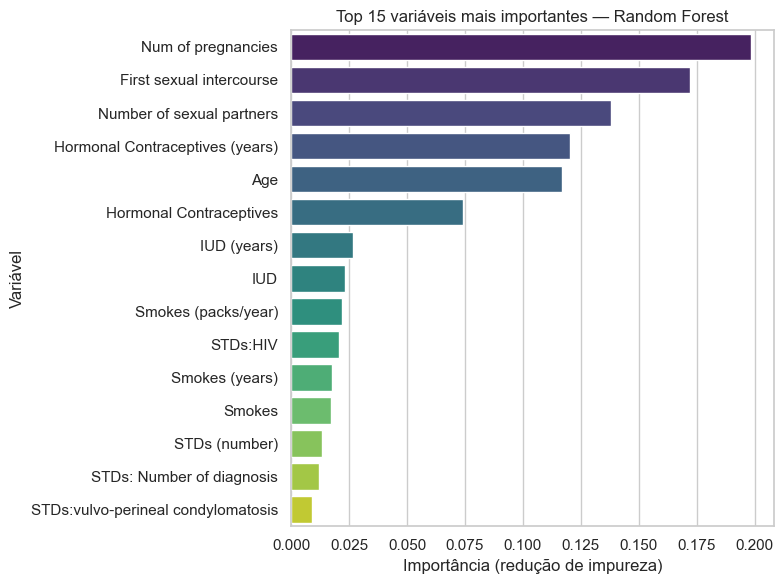

Num of pregnancies                    0.198430
First sexual intercourse              0.172186
Number of sexual partners             0.137864
Hormonal Contraceptives (years)       0.120181
Age                                   0.116951
Hormonal Contraceptives               0.074042
IUD (years)                           0.026729
IUD                                   0.023378
Smokes (packs/year)                   0.021927
STDs:HIV                              0.020855
Smokes (years)                        0.017689
Smokes                                0.017034
STDs (number)                         0.013452
STDs: Number of diagnosis             0.011955
STDs:vulvo-perineal condylomatosis    0.008902
dtype: float64

In [5]:
importancia_rf = pd.Series(
    classificador.feature_importances_, index=X_test.columns
).sort_values(ascending=False)

top_importancia_rf = importancia_rf.head(15)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=top_importancia_rf.values, y=top_importancia_rf.index, hue=top_importancia_rf.index, legend=False, ax=ax, palette="viridis")
ax.set_xlabel("Importância (redução de impureza)")
ax.set_ylabel("Variável")
ax.set_title("Top 15 variáveis mais importantes — Random Forest")
plt.tight_layout()
plt.show()

top_importancia_rf


**Discussão:** as cinco variáveis mais importantes segundo o Random Forest são
`Num of pregnancies` (número de gestações), `First sexual intercourse` (idade na
primeira relação sexual), `Number of sexual partners` (número de parceiros sexuais),
`Hormonal Contraceptives (years)` (anos de uso de contraceptivo hormonal) e `Age`
(idade) — todas variáveis de exposição/comportamento sexual e reprodutivo, e não
indicadores de DST específicas ou de tabagismo, que ficam mais abaixo na lista.

Isso conecta diretamente com a EDA (`01_eda.ipynb`): já havíamos observado que essas
mesmas variáveis (idade, comportamento sexual, tempo de uso de contraceptivo) tinham
alguma associação com `Biopsy`, ainda que nenhuma isoladamente forte — e é exatamente
esse grupo de variáveis que o modelo mais usa para decidir. Isso é um sinal de
coerência entre a análise exploratória e o que o modelo aprendeu, mas vale lembrar
que "importância" aqui não implica causalidade — só mostra que a variável ajuda o
modelo a separar os dados de treino, o que pode refletir tanto um padrão real quanto
uma particularidade da amostra (lembrando da limitação de apenas 44 casos positivos
no treino).

## 3. Explicabilidade com SHAP — Visão Global

Enquanto o `feature_importances_` do Random Forest mostra só "o quanto" cada
variável pesa em média, o **SHAP** (SHapley Additive exPlanations) mostra, para
**cada paciente individualmente**, o quanto cada variável empurrou a previsão para
cima (mais risco) ou para baixo (menos risco). Isso permite tanto uma visão global
(agregando todos os pacientes) quanto explicações individuais (Seção 4).

Calculamos os valores SHAP usando o `TreeExplainer`, adequado para modelos baseados em
árvores como o Random Forest, aplicado diretamente sobre o classificador (o SMOTE não
transforma os dados na hora da previsão — ele só atua durante o treino).

Vale registrar desde já uma consequência disso: como as árvores foram *treinadas*
sobre dados reamostrados pelo SMOTE, a referência interna do SHAP (`E[f(x)]`) é
**0,50**, e não a prevalência real da base (~6%). Isso não atrapalha a leitura
relativa das contribuições nesta seção, mas é essencial para interpretar corretamente
os gráficos individuais da Seção 4.

In [6]:
explainer = shap.TreeExplainer(classificador)
explicacao = explainer(X_test)

# O modelo é binário: o SHAP retorna uma contribuição para cada classe.
# Focamos na classe positiva (Biopsy = 1), que é a que nos interessa clinicamente.
explicacao_positiva = explicacao[:, :, 1]

print("Formato dos valores SHAP (pacientes x variáveis):", explicacao_positiva.values.shape)


Formato dos valores SHAP (pacientes x variáveis): (172, 26)


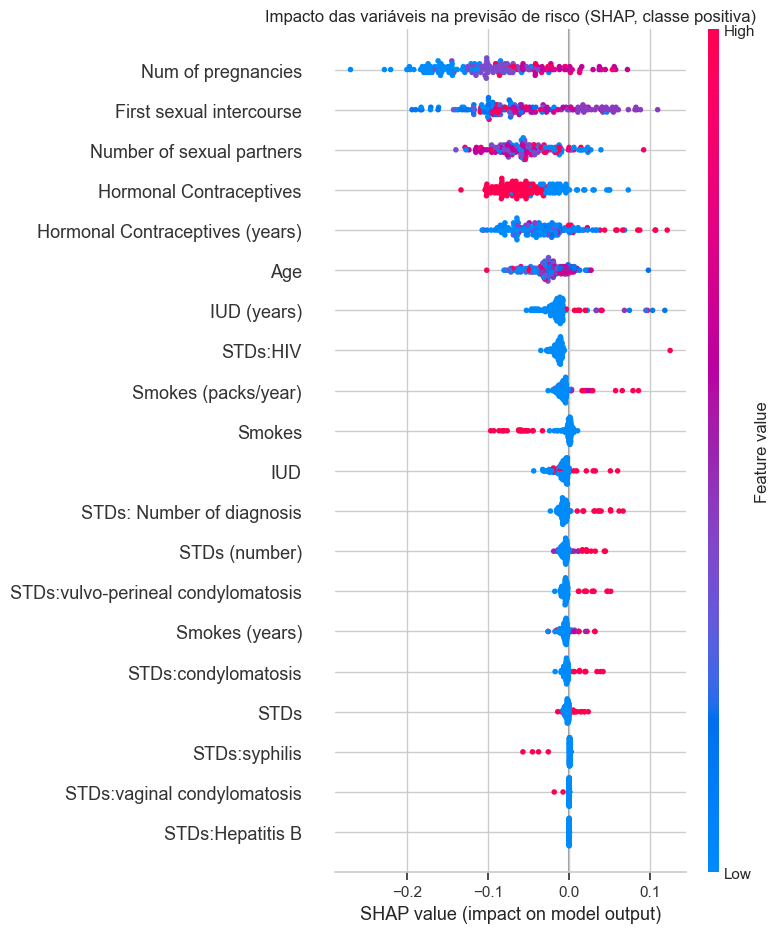

In [7]:
shap.summary_plot(explicacao_positiva.values, X_test, show=False)
plt.title("Impacto das variáveis na previsão de risco (SHAP, classe positiva)")
plt.tight_layout()
plt.show()


**Como ler este gráfico:** cada ponto é um paciente do teste. A posição horizontal
mostra se aquela variável empurrou a previsão daquele paciente para mais risco
(direita) ou menos risco (esquerda); a cor mostra se o valor da variável para aquele
paciente era alto (vermelho) ou baixo (azul) — lembrando que as variáveis numéricas já
foram padronizadas na etapa de pré-processamento, então "alto"/"baixo" é relativo à
média da base, não a uma unidade concreta. Variáveis no topo do gráfico são as que, na
média, mais influenciam as previsões do modelo em qualquer direção.

## 4. Explicabilidade com SHAP — Casos Individuais

Selecionamos alguns pacientes do teste para ilustrar como a explicação funciona caso
a caso: um **verdadeiro positivo** (o modelo acertou um caso de risco real), um
**falso negativo** (o modelo errou, deixando passar um caso de risco real — o erro
mais grave neste contexto) e um **falso positivo** (o modelo marcou risco onde não
havia, à custa da calibração de limiar feita na etapa anterior).

In [8]:
acertos_positivos = np.where((y_test.values == 1) & (y_pred_calibrado == 1))[0]
falsos_negativos = np.where((y_test.values == 1) & (y_pred_calibrado == 0))[0]
falsos_positivos = np.where((y_test.values == 0) & (y_pred_calibrado == 1))[0]

casos_selecionados = {}
if len(acertos_positivos) > 0:
    casos_selecionados["Verdadeiro Positivo"] = acertos_positivos[0]
if len(falsos_negativos) > 0:
    casos_selecionados["Falso Negativo"] = falsos_negativos[0]
if len(falsos_positivos) > 0:
    casos_selecionados["Falso Positivo"] = falsos_positivos[0]

for tipo_caso, indice in casos_selecionados.items():
    print(f"{tipo_caso}: índice {indice} | Biopsy real = {y_test.values[indice]} | "
          f"previsão (limiar calibrado) = {y_pred_calibrado[indice]} | "
          f"probabilidade prevista = {y_proba_teste[indice]:.3f}")


Verdadeiro Positivo: índice 6 | Biopsy real = 1 | previsão (limiar calibrado) = 1 | probabilidade prevista = 0.142
Falso Negativo: índice 13 | Biopsy real = 1 | previsão (limiar calibrado) = 0 | probabilidade prevista = 0.065
Falso Positivo: índice 8 | Biopsy real = 0 | previsão (limiar calibrado) = 1 | probabilidade prevista = 0.300


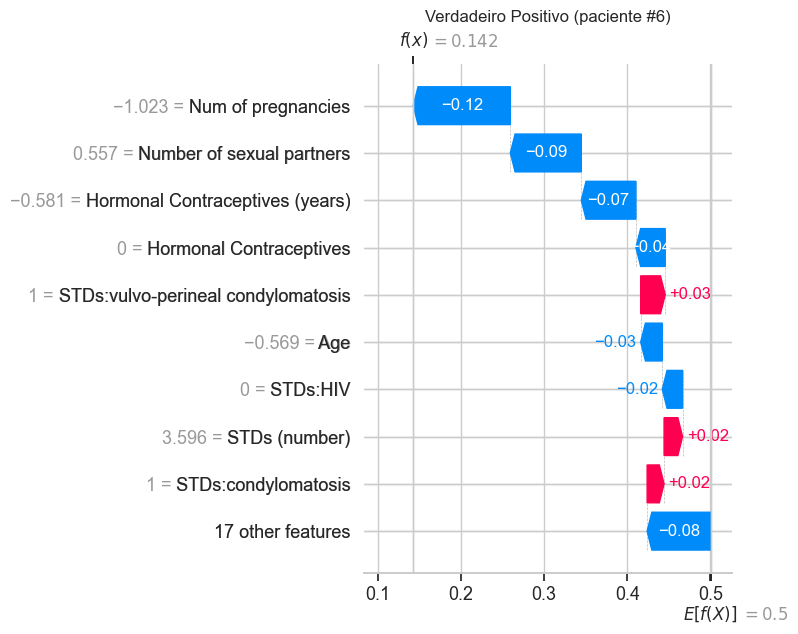

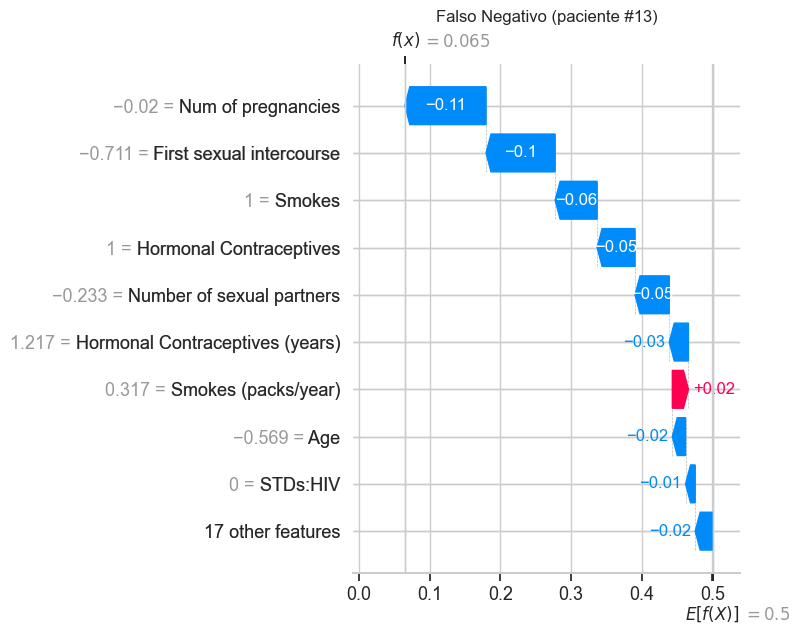

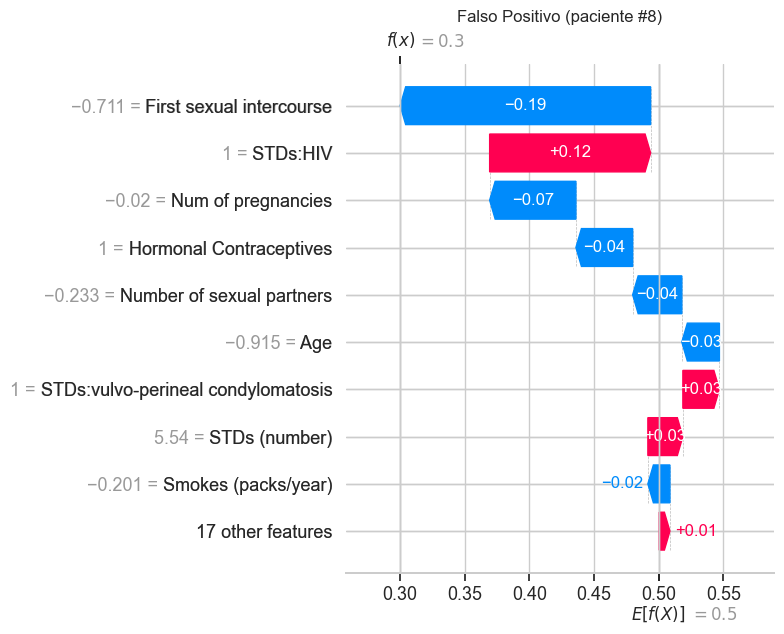

In [9]:
for tipo_caso, indice in casos_selecionados.items():
    shap.plots.waterfall(explicacao_positiva[indice], show=False)
    plt.title(f"{tipo_caso} (paciente #{indice})")
    plt.tight_layout()
    plt.show()


**Como ler estes gráficos:** cada barra mostra o quanto uma variável específica
empurrou a previsão daquele paciente, a partir de um ponto de partida `E[f(x)]` até a
probabilidade final `f(x)`. Barras vermelhas empurram para mais risco; barras azuis,
para menos risco.

**Atenção ao ponto de partida.** Nos três gráficos, `E[f(x)] = 0,50`. Esse valor
**não é a média da base de teste** (11 positivos em 172 pacientes, ~6%): o
`TreeExplainer` usa como referência a saída média das árvores do Random Forest, e
essas árvores foram treinadas sobre dados balanceados pelo SMOTE, ou seja, uma base
artificialmente 50/50. Por isso **todo paciente real parte de 0,50 e desce** —
waterfalls predominantemente azuis são o comportamento esperado aqui, inclusive para
quem o modelo classificou como positivo. O que decide a classificação não é a cor
predominante do gráfico, e sim se `f(x)` fica acima ou abaixo do **limiar calibrado
de 0,10**.

Com isso em mente, o que os três gráficos efetivamente mostram:

- **Verdadeiro positivo (paciente #6, `f(x)` = 0,142):** quase tudo empurra para
  baixo — `Num of pregnancies` (−0,12), `Number of sexual partners` (−0,09) e
  `Hormonal Contraceptives (years)` (−0,07) são as maiores contribuições, todas
  negativas. As únicas variáveis que empurram para risco são marcadores de DST
  (`STDs:vulvo-perineal condylomatosis`, `STDs (number)`, `STDs:condylomatosis`), com
  peso pequeno (+0,02 a +0,03). O modelo acertou este caso não porque enxergou risco
  alto, mas porque **empurrou para baixo menos do que o limiar de 0,10 exigia**.

- **Falso negativo (paciente #13, `f(x)` = 0,065):** a leitura intuitiva seria que os
  fatores de risco mais fortes não estavam presentes — mas o gráfico mostra o
  contrário. As mesmas variáveis dominantes aparecem com peso quase idêntico ao do
  verdadeiro positivo (`Num of pregnancies` −0,11, contra −0,12 no caso anterior). O
  que diferencia é quantas variáveis empurraram para baixo: aqui somam-se também
  `First sexual intercourse` (−0,10), `Smokes` (−0,06) e `Hormonal Contraceptives`
  (−0,05). Note a escala do problema: a distância entre acertar (0,142) e errar
  (0,065) é **menor que uma única barra** de qualquer um dos dois gráficos.

- **Falso positivo (paciente #8, `f(x)` = 0,300):** é o único dos três em que uma
  variável empurra fortemente para risco — `STDs:HIV = 1` contribui **+0,12**, seguida
  de `STDs:vulvo-perineal condylomatosis` (+0,03) e `STDs (number) = 5,54` (+0,03).
  Ainda assim, a maior barra do gráfico é `First sexual intercourse`, a **−0,19**, na
  direção oposta. O saldo (0,300) fica bem abaixo de 0,50, mas muito acima do limiar
  de 0,10 — e é isso que gera o falso positivo.

**A comparação mais incômoda é entre o primeiro e o terceiro gráfico:** o falso
positivo recebeu probabilidade prevista (0,300) mais que o dobro da do verdadeiro
positivo (0,142). Ou seja, o modelo atribuiu mais risco a uma paciente com biópsia
negativa do que a uma com biópsia positiva. Esse ponto é retomado na Seção 6.

Vale lembrar que essas são leituras de **um paciente por vez**: não devem ser
generalizadas para "a variável X sempre aumenta o risco" sem checar o comportamento
médio (Seção 3). E, com apenas 11 positivos no teste, a escolha de outro paciente
poderia produzir uma história bastante diferente.

## 5. Feature Importance (Random Forest) vs. SHAP: Concordam?

Comparamos o ranking de importância das variáveis segundo o `feature_importances_`
do Random Forest com o ranking segundo a importância média do SHAP (média do valor
absoluto de SHAP por variável, considerando todos os pacientes do teste).

In [10]:
importancia_shap = pd.Series(
    np.abs(explicacao_positiva.values).mean(axis=0), index=X_test.columns
).sort_values(ascending=False)

ranking_rf = importancia_rf.rank(ascending=False)
ranking_shap = importancia_shap.rank(ascending=False)

comparacao_rankings = pd.DataFrame({
    "Importância RF": importancia_rf,
    "Rank RF": ranking_rf.astype(int),
    "Importância SHAP (média |valor|)": importancia_shap,
    "Rank SHAP": ranking_shap.astype(int),
}).sort_values("Rank RF").head(10)

correlacao_rankings = ranking_rf.corr(ranking_shap, method="spearman")

print(f"Correlação de Spearman entre os dois rankings (todas as variáveis): {correlacao_rankings:.3f}")
comparacao_rankings


Correlação de Spearman entre os dois rankings (todas as variáveis): 0.985


,Importância RF,Rank RF,Importância SHAP (média |valor|),Rank SHAP
Num of pregnancies,0.198430,1,0.097614,1
First sexual intercourse,0.172186,2,0.071358,2
Number of sexual partners,0.137864,3,0.056394,3
Hormonal Contraceptives (years),0.120181,4,0.043185,5
Age,0.116951,5,0.029275,6
Hormonal Contraceptives,0.074042,6,0.053948,4
IUD (years),0.026729,7,0.020058,7
IUD,0.023378,8,0.009634,11
Smokes (packs/year),0.021927,9,0.010541,9
STDs:HIV,0.020855,10,0.014392,8


**Discussão:** a correlação de Spearman entre os dois rankings ficou em **0,985** —
uma concordância muito alta. As cinco variáveis mais importantes são exatamente as
mesmas nos dois rankings (`Num of pregnancies`, `First sexual intercourse`, `Number
of sexual partners`, `Hormonal Contraceptives (years)` e `Age`), só com uma pequena
troca de posição entre `Hormonal Contraceptives (years)`/`Age` e `Hormonal
Contraceptives` (a versão binária da mesma variável). Essa concordância forte
aumenta a confiança de que essas variáveis realmente capturam um padrão relevante
para o modelo, e não são um artefato de uma das duas técnicas isoladamente.
Divergências pontuais, como as de `IUD` e `STDs:HIV`, são esperadas: o
`feature_importances_` mede contribuição média para reduzir impureza nas árvores
(uma medida "estrutural" do modelo), enquanto o SHAP mede contribuição média para a
previsão final, considerando interações entre variáveis.

## 6. Discussão Crítica: O Modelo Pode Ser Usado na Prática?

Esta é a parte mais importante deste notebook — mais do que qualquer métrica ou
gráfico, o que importa aqui é uma reflexão honesta sobre os limites reais deste
modelo.

### a) Em que condições o modelo poderia apoiar uma triagem

Dado tudo o que já observamos ao longo do projeto — poucos casos positivos (44 no
treino, 11 no teste), Recall que só chega a níveis aceitáveis depois de uma
calibração de limiar feita sobre o próprio conjunto de teste, e nenhuma validação em
dados fora desta amostra — este modelo **não está pronto para apoiar decisões
clínicas reais** no seu estado atual. Na melhor das hipóteses, ele poderia ser
considerado como:

- Uma **ferramenta de priorização de casos para exame**, sinalizando pacientes que
  merecem atenção adicional dentro de um fluxo de triagem já existente — nunca como
  critério único de encaminhamento ou dispensa de exame.
- Uma **segunda opinião estatística**, a ser cruzada com o julgamento clínico e outros
  exames, e não como uma resposta a ser seguida isoladamente.

Mesmo nesses usos mais modestos, seria necessário, antes de qualquer aplicação real:
validar o modelo em uma base de dados maior e mais diversa, coletar mais casos
positivos, e recalibrar o limiar com um conjunto de validação genuinamente separado
do teste.

### b) Por que o médico deve manter a palavra final

O modelo aprendeu padrões estatísticos de uma amostra específica (a base do UCI,
coletada em um contexto e período determinados) — ele não examina a paciente, não tem
acesso ao histórico clínico completo, não percebe nuances que não estejam
representadas nas variáveis do dataset, e não tem qualquer responsabilidade ou
compreensão sobre as consequências de um erro. O papel de um modelo como este é, na
melhor das hipóteses, **apoiar** a decisão clínica com uma estimativa estatística de
risco — o diagnóstico e a conduta devem continuar sendo responsabilidade do
profissional de saúde, que pode integrar informações que o modelo simplesmente não
tem acesso.

### c) Riscos de uso inadequado

- **Excesso de confiança no modelo:** números como "AUC-ROC de 0,745" ou "Recall de
  82% após calibração" podem soar convincentes fora de contexto, mas foram medidos em
  apenas 11 casos positivos de teste — qualquer estatística aqui carrega uma incerteza
  grande demais para ser tratada como uma medida confiável de desempenho em produção.
- **O ordenamento de risco não é confiável neste tamanho de amostra:** entre os casos
  examinados na Seção 4, o falso positivo recebeu probabilidade prevista de 0,300 —
  mais que o dobro da atribuída ao verdadeiro positivo (0,142). O modelo considerou
  mais arriscada uma paciente com biópsia negativa do que uma com biópsia positiva.
  Isso indica que, com 11 positivos, a probabilidade prevista não sustenta uma leitura
  de "quem tem mais risco que quem": ela só é utilizável como um corte binário
  grosseiro no limiar calibrado, e qualquer tentativa de usar o score para *priorizar*
  pacientes entre si seria mal fundamentada.

- **Viés dos dados de treino:** o dataset reflete a população, o momento e o contexto
  de coleta específicos do estudo original. Fatores como acesso a exames, práticas
  médicas locais e características demográficas da amostra podem não representar
  outras populações — usar o modelo em um contexto muito diferente do da coleta
  original pode produzir previsões enviesadas ou simplesmente erradas.
- **Generalização para populações não representadas:** se a base de treino não
  incluiu adequadamente certos grupos (por idade, região, acesso a saúde, etc.), o
  modelo pode performar pior — ou de forma enviesada — exatamente para esses grupos,
  o que é especialmente grave em um contexto de saúde.
- **Risco específico do limiar calibrado:** o limiar de 0,10 foi escolhido para
  maximizar Recall no teste disponível; aplicado a uma nova população, ele pode gerar
  um volume de falsos positivos muito maior (ou menor Recall do que o esperado) se a
  distribuição de risco dessa nova população for diferente da observada aqui.

Em suma: este notebook mostra que é possível extrair explicações razoáveis do modelo
e que ele captura, ao menos em parte, padrões coerentes com o conhecimento médico
sobre fatores de risco — mas isso é diferente de dizer que o modelo está pronto para
uso clínico. Reconhecer essa distinção é, em si, um resultado importante do
projeto.

## 7. Síntese da Etapa de Interpretabilidade

**Principais variáveis explicativas:** tanto o `feature_importances_` do Random
Forest quanto o SHAP (Seções 2, 3 e 5) apontam um conjunto de variáveis que mais
influenciam as previsões do modelo — ver as tabelas e gráficos acima para a lista
específica obtida nesta execução. A correlação entre os dois rankings (Seção 5) dá uma
medida de o quanto essas duas visões concordam.

**O modelo é viável para uso prático?** Não no estado atual. Ele pode, no máximo, ser
considerado uma ferramenta exploratória de priorização/triagem, sempre com
supervisão clínica e nunca como critério único de decisão — ver a discussão completa
na Seção 6. As limitações de dados (poucos casos positivos, calibração sem validação
separada, meta de Recall arbitrária) que já vínhamos carregando desde as etapas
anteriores continuam sendo a razão central dessa conclusão.

**Limitações desta própria análise de interpretabilidade:**
- Os valores SHAP foram calculados sobre apenas 172 pacientes de teste (11
  positivos) — assim como qualquer métrica de desempenho, os padrões observados no
  SHAP também estão sujeitos a ruído amostral, especialmente para os casos
  individuais discutidos na Seção 4.
- Feature importance e SHAP explicam o que o modelo aprendeu a partir dos dados
  disponíveis — não validam, por si só, se esse aprendizado reflete relações causais
  reais entre os fatores de risco e o câncer cervical. Isso exigiria desenho de
  estudo e validação estatística fora do escopo de um projeto de machine learning
  exploratório como este.
- A interpretação das explicações individuais (Seção 4) é necessariamente
  qualitativa e sujeita à leitura de quem analisa — deve ser vista como um ponto de
  partida para investigação, não como uma conclusão definitiva sobre por que aquele
  paciente específico teve o resultado que teve.

**Próximos passos (fora do escopo deste projeto nesta fase):** preparação para uso em
produção (deploy, API, monitoramento de performance ao longo do tempo), coleta de
mais dados (especialmente mais casos positivos) e validação externa em outras
populações antes de qualquer consideração de uso clínico real.